In [20]:
import pandas as pd 

In [22]:
print("Pandas version: ", pd.__version__)

Pandas version:  3.0.5


In [23]:
file_path = "../data/13059_2018_1459_MOESM5_ESM.xlsx"

In [24]:
excel_file = pd.ExcelFile(file_path)
print(excel_file.sheet_names)

['hct116', 'hek293t', 'hela', 'hl60']


In [25]:
df = pd.read_excel(file_path, sheet_name="hct116")

In [26]:
df.head()

,Chromosome,Start,End,Strand,sgRNA,Normalized efficacy
0,chr17,33469132,33469154,-,CTTGCTCGCGCAGGACGAGGCGG,0.164020
1,chr4,184605984,184606006,-,ACATCAGGTTACCTCTACCAAGG,0.311196
2,chr1,11736866,11736888,+,CTGATGCCAGCTAGTGGGCGAGG,0.179397
3,chr4,25379067,25379089,+,CTGTTTCCCATCCTTCCGGGTGG,0.498712
4,chr12,57936737,57936759,-,AATGTATGCACAGGGAACAGAGG,0.233023


In [27]:
df.shape

(4239, 6)

In [28]:
df.columns

Index(['Chromosome', 'Start', 'End', 'Strand', 'sgRNA', 'Normalized efficacy'], dtype='str')

In [ ]:
# Check the datatypes
df.dtypes

Chromosome                 str
Start                    int64
End                      int64
Strand                     str
sgRNA                      str
Normalized efficacy    float64
dtype: object

In [30]:
# Dataset summary
df.info

<bound method DataFrame.info of      Chromosome      Start        End Strand                    sgRNA  \
0         chr17   33469132   33469154      -  CTTGCTCGCGCAGGACGAGGCGG   
1          chr4  184605984  184606006      -  ACATCAGGTTACCTCTACCAAGG   
2          chr1   11736866   11736888      +  CTGATGCCAGCTAGTGGGCGAGG   
3          chr4   25379067   25379089      +  CTGTTTCCCATCCTTCCGGGTGG   
4         chr12   57936737   57936759      -  AATGTATGCACAGGGAACAGAGG   
...         ...        ...        ...    ...                      ...   
4234      chr17   45738523   45738545      +  CACACAGTGTCCAGATACGAGGG   
4235       chr6  160205680  160205702      +  CCAAATCCCAAACCTTACCCTGG   
4236      chr16   10851836   10851858      -  CATCGATGTGTGCTGTGGCCAGG   
4237      chr14  102815058  102815080      -  GCTCTTGGAGATGTACAGGAAGG   
4238       chr1   28661208   28661230      +  GATGGAAATGGGCTTCCGCATGG   

      Normalized efficacy  
0                0.164020  
1                0.311196  
2      

In [ ]:
# Check for missing values

df.isnull().sum()

Chromosome             0
Start                  0
End                    0
Strand                 0
sgRNA                  0
Normalized efficacy    0
dtype: int64

In [34]:
# Check the sgRNA lengths

df["sgRNA"].str.len().value_counts()

sgRNA
23    4239
Name: count, dtype: int64

In [35]:
# Check which nucleotides occur

unique_bases = set("".join(df["sgRNA"]))
print(unique_bases)

{'A', 'C', 'T', 'G'}


In [36]:
# Examine the efficiacy values

df["Normalized efficacy"].describe()

count    4239.000000
mean        0.254276
std         0.171743
min         0.000276
25%         0.121268
50%         0.209607
75%         0.360118
max         0.945898
Name: Normalized efficacy, dtype: float64

In [37]:
# Look at few sequences manually
df["sgRNA"].head(10)

0    CTTGCTCGCGCAGGACGAGGCGG
1    ACATCAGGTTACCTCTACCAAGG
2    CTGATGCCAGCTAGTGGGCGAGG
3    CTGTTTCCCATCCTTCCGGGTGG
4    AATGTATGCACAGGGAACAGAGG
5    CCAGACTCACCCGCTTGCCCAGG
6    CATCAGACGCCTCCAGCCGCCGG
7    CCTTGAACTTGAGCAACAACAGG
8    GGCTTCTTCCAAGCGACCCAGGG
9    GCACGAGGCTGGGTCGAAGACGG
Name: sgRNA, dtype: str

In [ ]:
# Histogram to represent Normalized efficacy V/S Number of sgRNA
import matplotlib.pyplot as plt

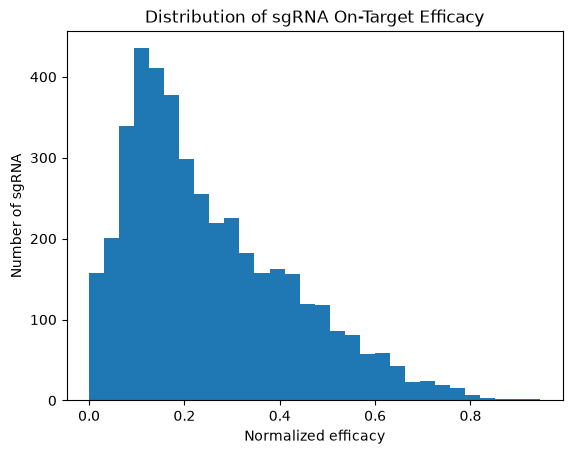

In [39]:
plt.hist(df["Normalized efficacy"], bins=30)
plt.xlabel("Normalized efficacy")
plt.ylabel("Number of sgRNA")
plt.title("Distribution of sgRNA On-Target Efficacy")
plt.show()

In [44]:
# Check for duplicate sgRNAs
duplicate_count = df["sgRNA"].duplicated().sum()
print("Duplicate sgRNA: ", duplicate_count)

Duplicate sgRNA:  0


In [ ]:
#Load all four cell lines 

cell_lines = ["hct116", "hek293t", "hela", "hl60"]

dataframes = {}

for cell_line in cell_lines:
    dataframes[cell_line] = pd.read_excel(
        file_path, sheet_name= cell_line
    )

In [ ]:
#Check the size of each dataset

for cell_line in cell_lines:
    print(cell_line, dataframes[cell_line].shape)


hct116 (4239, 6)
hek293t (2333, 6)
hela (8101, 6)
hl60 (2076, 6)


In [ ]:
# Add cell line information

for cell_line in cell_lines:
    dataframes[cell_line]["Cell line"] = cell_line

In [ ]:
# Combining all sheets
all_data = pd.concat(dataframes.values(), ignore_index= True )

In [ ]:
#Check the all_data size 
all_data.shape

(16749, 7)

In [63]:
all_data.head()

,Chromosome,Start,End,Strand,sgRNA,Normalized efficacy,Cell line
0,chr17,33469132,33469154,-,CTTGCTCGCGCAGGACGAGGCGG,0.164020,hct116
1,chr4,184605984,184606006,-,ACATCAGGTTACCTCTACCAAGG,0.311196,hct116
2,chr1,11736866,11736888,+,CTGATGCCAGCTAGTGGGCGAGG,0.179397,hct116
3,chr4,25379067,25379089,+,CTGTTTCCCATCCTTCCGGGTGG,0.498712,hct116
4,chr12,57936737,57936759,-,AATGTATGCACAGGGAACAGAGG,0.233023,hct116


In [ ]:
# Count observations by cell line 
all_data["Cell line"].value_counts()

Cell line
hela       8101
hct116     4239
hek293t    2333
hl60       2076
Name: count, dtype: int64

In [78]:
# Find repeated sgRNAs

sgRNA_counts = all_data["sgRNA"].value_counts()
repeated_sgRNAs = sgRNA_counts[sgRNA_counts > 1]
print("Total unique sgRNAs:", all_data["sgRNA"].nunique())
print("Repeated sgRNAs:", len(repeated_sgRNAs))

Total unique sgRNAs: 12465
Repeated sgRNAs: 4217


In [88]:
example_sgRNA = reapeated_sgRNAs.index[0]
print("Example sgRNA: ", example_sgRNA)

Example sgRNA:  CGGCACATCGTAGAGACGCACGG


In [89]:
all_data[all_data["sgRNA"] == example_sgRNA][["sgRNA", "Normalized efficacy", "Cell line"]]

,sgRNA,Normalized efficacy,Cell line
52,CGGCACATCGTAGAGACGCACGG,0.772815,hct116
6623,CGGCACATCGTAGAGACGCACGG,0.364399,hela
14681,CGGCACATCGTAGAGACGCACGG,0.427674,hl60


<Figure size 800x500 with 0 Axes>

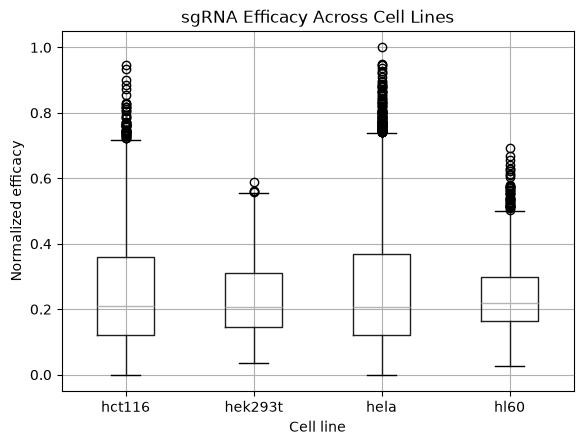

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

all_data.boxplot(
    column="Normalized efficacy",
    by="Cell line"
)

plt.xlabel("Cell line")
plt.ylabel("Normalized efficacy")
plt.title("sgRNA Efficacy Across Cell Lines")

plt.suptitle("")

plt.show()

In [96]:
sgRNA_cell_line_count = (
    all_data.groupby("sgRNA")["Cell line"]
    .nunique()
)

print(sgRNA_cell_line_count.value_counts().sort_index())

Cell line
1    8248
2    4150
3      67
Name: count, dtype: int64
